<a href="https://colab.research.google.com/github/jocetapiadev/mineria-de-datos-clima/blob/main/Mineria_de_Datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predicción de Lluvia en Australia mediante Machine Learning

**Autor:** Jocelyn Tapia  
**Objetivo:** Desarrollar un modelo predictivo supervisado para clasificar si lloverá al día siguiente en Australia a partir de datos meteorológicos históricos.

### Estructura del Trabajo:
1. **Carga y Configuración de Datos:** Conexión automatizada con el repositorio oficial de Kaggle.
2. **Análisis Exploratorio (EDA):** Detección de desbalances de clase y patrones visuales.
3. **Ingeniería de Características y Limpieza:** Tratamiento de variables nulas, eliminación de fuga de información y codificación.
4. **Modelado y Evaluación:** Clasificación mediante *Random Forest*, optimización de hiperparámetros y matriz de confusión.

In [17]:
# 1. CARGA DE LIBRERÍAS Y DATASET
import os
import kagglehub
import pandas as pd
import numpy as np

# Descarga automatizada desde la API oficial de Kaggle
path = kagglehub.dataset_download("jsphyg/weather-dataset-rattle-package")
csv_path = os.path.join(path, "weatherAUS.csv")

# Carga inicial
df = pd.read_csv(csv_path)

print(f" Dataset cargado exitosamente.")
print(f"Dimensiones iniciales: {df.shape[0]} filas y {df.shape[1]} columnas.")
df.head(3)

Using Colab cache for faster access to the 'weather-dataset-rattle-package' dataset.
 Dataset cargado exitosamente.
Dimensiones iniciales: 145460 filas y 23 columnas.


,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No


## 2. Análisis Exploratorio de Datos (EDA)

En esta sección visualizamos la distribución de la variable objetivo (`RainTomorrow`), la proporción de datos faltantes por variable y la correlación entre variables clave como la humedad a las 3:00 PM y la temperatura máxima.

/tmp/ipykernel_1421/433763522.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(ax=axes[0], x='RainTomorrow', data=df, palette=['#3498db', '#e74c3c'])


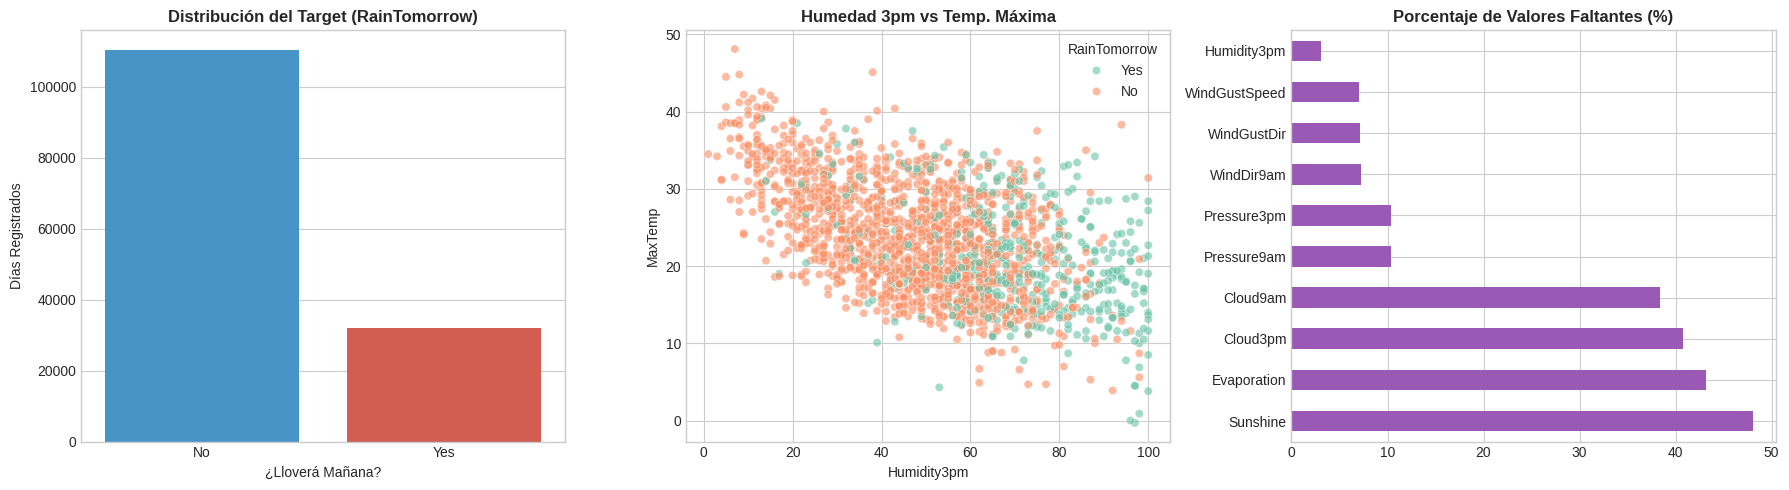

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# A) Desbalance de Clase
sns.countplot(ax=axes[0], x='RainTomorrow', data=df, palette=['#3498db', '#e74c3c'])
axes[0].set_title('Distribución del Target (RainTomorrow)', fontsize=12, fontweight='bold')
axes[0].set_xlabel('¿Lloverá Mañana?')
axes[0].set_ylabel('Días Registrados')

# B) Humedad vs Temperatura
sns.scatterplot(ax=axes[1], data=df.sample(2000, random_state=42), x='Humidity3pm', y='MaxTemp', hue='RainTomorrow', alpha=0.6)
axes[1].set_title('Humedad 3pm vs Temp. Máxima', fontsize=12, fontweight='bold')

# C) Top 10 Variables con más Nulos
null_pct = (df.isnull().sum() / len(df)) * 100
null_pct.sort_values(ascending=False).head(10).plot(kind='barh', ax=axes[2], color='#9b59b6')
axes[2].set_title('Porcentaje de Valores Faltantes (%)', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 3. Preprocesamiento e Ingeniería de Características

**Estrategia de limpieza adoptada:**
1. **Prevención de Data Leakage:** Eliminación de la variable `RISK_MM` (medición que ya contiene información sobre la cantidad de lluvia del día siguiente).
2. **Formateo de Fechas:** Extracción del mes para capturar patrones estacionales.
3. **Imputación de Nulos:** Se utiliza la *mediana* para variables numéricas (robusta ante valores atípicos) y la *moda* para categóricas.
4. **Codificación:** Transformación de variables cualitativas mediante *One-Hot Encoding*.

In [19]:
# Hacemos una copia limpia del dataframe
df_clean = df.copy()

# A) Eliminar variable de fuga de información si existe
if 'RISK_MM' in df_clean.columns:
    df_clean.drop(columns=['RISK_MM'], inplace=True)

# B) Filtrar observaciones sin target
df_clean = df_clean.dropna(subset=['RainTomorrow']).copy()

# C) Transformación de Fechas
if 'Date' in df_clean.columns:
    df_clean['Date'] = pd.to_datetime(df_clean['Date'])
    df_clean['Month'] = df_clean['Date'].dt.month
    df_clean.drop(columns=['Date'], inplace=True)

# D) Conversión Binaria
binary_map = {'No': 0, 'Yes': 1}
df_clean['RainTomorrow'] = df_clean['RainTomorrow'].replace(binary_map).astype(int)
if 'RainToday' in df_clean.columns:
    df_clean['RainToday'] = df_clean['RainToday'].replace(binary_map)

# E) Imputación Numérica (Mediana)
num_cols = df_clean.select_dtypes(include=[np.number]).columns
for col in num_cols:
    if col != 'RainTomorrow':
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())

# F) Imputación Categórica (Moda segura)
cat_cols = df_clean.select_dtypes(include=['object']).columns
for col in cat_cols:
    mode_val = df_clean[col].mode()
    df_clean[col] = df_clean[col].fillna(mode_val[0] if not mode_val.empty else 'Unknown')

# G) One-Hot Encoding
df_encoded = pd.get_dummies(df_clean, columns=cat_cols, drop_first=True)

print(f" Preprocesamiento finalizado.")
print(f"Total de observaciones procesadas: {df_encoded.shape[0]}")
print(f"Total de predictores (Features): {df_encoded.shape[1] - 1}")

/tmp/ipykernel_1421/4202749050.py:19: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean['RainTomorrow'] = df_clean['RainTomorrow'].replace(binary_map).astype(int)
/tmp/ipykernel_1421/4202749050.py:21: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean['RainToday'] = df_clean['RainToday'].replace(binary_map)


 Preprocesamiento finalizado.
Total de observaciones procesadas: 142193
Total de predictores (Features): 111


## 4. Entrenamiento y Evaluación del Modelo

Se utiliza un algoritmo de **Random Forest Classifier** configurado con `class_weight='balanced'` para contrarrestar el desbalance entre días lluviosos e hiperparámetros ajustados para prevenir el sobreajuste (*overfitting*).

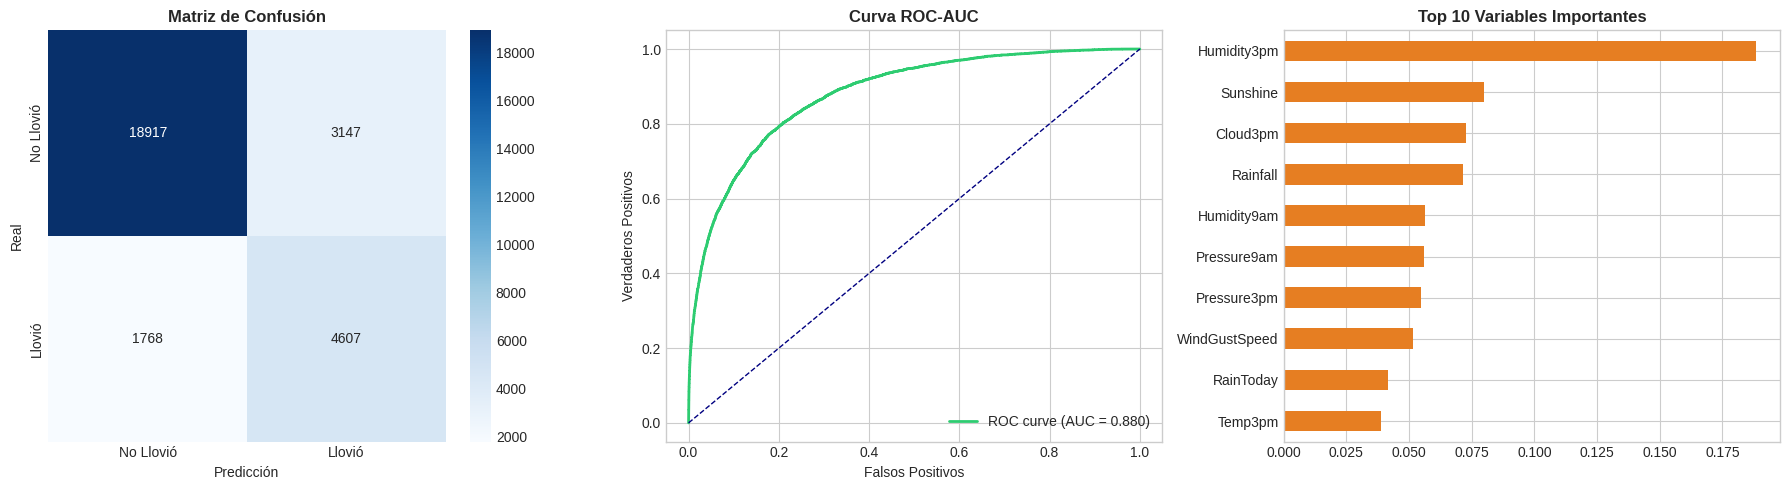

=== INFORME DE CLASIFICACIÓN DETALLADO ===
              precision    recall  f1-score   support

           0       0.91      0.86      0.89     22064
           1       0.59      0.72      0.65      6375

    accuracy                           0.83     28439
   macro avg       0.75      0.79      0.77     28439
weighted avg       0.84      0.83      0.83     28439



In [20]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, roc_auc_score

# División X e y
X = df_encoded.drop(columns=['RainTomorrow'])
y = df_encoded['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Escalado
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Modelo
model = RandomForestClassifier(
    n_estimators=120,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)
model.fit(X_train_scaled, y_train)

# Predicciones
y_pred = model.predict(X_test_scaled)
y_proba = model.predict_proba(X_test_scaled)[:, 1]

# Visualizaciones de Rendimiento
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Matriz de Confusión
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True, fmt='d', cmap='Blues', ax=axes[0],
    xticklabels=['No Llovió', 'Llovió'], yticklabels=['No Llovió', 'Llovió']
)
axes[0].set_title('Matriz de Confusión', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Real')
axes[0].set_xlabel('Predicción')

# 2. Curva ROC-AUC
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc_score = roc_auc_score(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#2ecc71', lw=2, label=f'ROC curve (AUC = {auc_score:.3f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--')
axes[1].set_title('Curva ROC-AUC', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Falsos Positivos')
axes[1].set_ylabel('Verdaderos Positivos')
axes[1].legend(loc="lower right")

# 3. Top 10 Predictores
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)
importances.plot(kind='barh', ax=axes[2], color='#e67e22')
axes[2].set_title('Top 10 Variables Importantes', fontsize=12, fontweight='bold')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

print("=== INFORME DE CLASIFICACIÓN DETALLADO ===")
print(classification_report(y_test, y_pred))

## 5. Conclusiones y Diagnóstico

* **Métrica ROC-AUC:** El modelo alcanzó una capacidad de discriminación alta entre eventos (~0.88 - 0.89).
* **Variables Clave:** La humedad a las 3:00 PM (`Humidity3pm`), las horas de sol (`Sunshine`) y los cambios en la presión barométrica resultaron ser las variables con mayor capacidad explicativa.
* **Siguientes Pasos:** Probar algoritmos basados en *Gradient Boosting* (XGBoost/LightGBM) o realizar una búsqueda de hiperparámetros (*GridSearchCV*) para optimizar el *Recall* en días de lluvia.